# Estimating covariance of ECF estimators

Here, we investigate methods for estimating the covariance of the ECF estimator.

References: 
K. C. Tran, _Estimating mixtures of normal distributions via empirical characteristic function_, Econ. Rev. 17 DOI: 10.1080/07474939808800410

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fppanalysis as fa
from fppanalysis.parameter_estimation_ECF import _error_covariance_num, _error_covariance_an
import closedexpressions as ce
import ECF_support as ecfs

from scipy.optimize import curve_fit, Bounds, minimize
import scipy.linalg as slg

In [2]:
# Set up the distributions we use as examples
Distlist = [ecfs.DistributionFamily('exponential',
                                    fa.CF_exp, fa.CF_jac_exp, np.random.exponential,
                                    [1.,], ['lam',], Bounds(1e-6,100)),
            ecfs.DistributionFamily('exponential', 
                                    fa.CF_exp, fa.CF_jac_exp, np.random.exponential, 
                                    [2.,], ['lam',], Bounds(1e-6,100)),
            ecfs.DistributionFamily('gamma', 
                                    fa.CF_gamma, fa.CF_jac_gamma, np.random.gamma, 
                                    [2., 1.], ['gamma', 'theta'], Bounds((1e-6,1e-6),(10,10))),
            ecfs.DistributionFamily('gammanorm', 
                                    fa.CF_gamma_norm, fa.CF_jac_gamma_norm, ecfs.generator_gamma_norm, 
                                    [2., ], ['gamma',], Bounds(1e-6,10)),
            ecfs.DistributionFamily('normal', 
                                    fa.CF_norm, fa.CF_jac_norm, np.random.normal, 
                                    [0.1,1.], ['mu', 'sigma'], Bounds((-10,1e-6),(10,100))),
            ecfs.DistributionFamily('normal',
                                    fa.CF_norm, fa.CF_jac_norm, np.random.normal, 
                                    [1.,2.], ['mu', 'sigma'], Bounds((-10,1e-6),(10,100))),
            ecfs.DistributionFamily('fpp',
                                    fa.CF_gamma_gauss_norm, fa.CF_jac_gamma_gauss_norm, ecfs.generator_gamma_gauss_norm,
                                    [1., 0.1], ['gamma', 'eps'], Bounds((1e-6,1e-6),(10,10))),
            ecfs.DistributionFamily('fpp',
                                    fa.CF_gamma_gauss_norm, fa.CF_jac_gamma_gauss_norm, ecfs.generator_gamma_gauss_norm,
                                    [5., 0.5], ['gamma', 'eps'], Bounds((1e-6,1e-6),(10,10))),
           ]

## Investigate the covariance matrix estimators
We need a consistent estimator for the covariance matrix. The two most basic options are:

 - Make a numerical estimate only based on the data, as in `fppanalysis.parameter_estimation_ECF._error_covariance_num`
 - Use `fppanalysis.parameter_estimation_ECF._error_covariance_an`, which requires a guess for the parameters.

We also look into the condition numbers.

### Takeaways

 - The numerical estimator converges.
 - Close to the true value, the analytic estimate is quite close.

 - Estimate normalized data if possible, this regularizes the condition numbers.
 - Condition numbers for the numerical case are in general quite close to the true values for $>10^4$ samples.
 - Only exponential and un-normalized gamma cases have significant deviations in the condition number.

### Numerical estimate 

The following calculation suggests that `fppanalysis.parameter_estimation_ECF._error_covariance_num` is a consistent estimator of `fppanalysis.parameter_estimation_ECF._error_covariance_an`, as the relative error decreases for larger sample size.

In [ ]:
def check_consistent_error_cov_estimator_num(Dist, samples_arr = (10.**np.arange(3,6)).astype(int)):
    u = np.arange(1,11)
    
    C = _error_covariance_an(u,Dist.params,Dist.CF)

    max_dist = np.zeros(samples_arr.size)
    std_dist = np.zeros(samples_arr.size)
    for i in range(samples_arr.size):
        Cnum = _error_covariance_num(u,Dist.realization(samples_arr[i]))
        max_dist[i] = np.max(np.abs(C-Cnum))/np.mean(np.abs(C))
        std_dist[i] = np.std(C-Cnum)/np.std(C)

    label = 'Distance from true to numerical error covariance for ' + Dist.name + f'{Dist.params}'
    plt.figure(label)
    plt.title(label)
    plt.loglog(samples_arr, max_dist, 'd', label=r'$\mathrm{max}\,\left| C-C_\mathrm{num} \right|/\langle  \left| C\right|\rangle$')
    plt.loglog(samples_arr, std_dist, 'd', label=r'$(C-C_\mathrm{num})_\mathrm{rms} / C_\mathrm{rms}$')
    plt.legend()
    
    plt.xlabel('samples')

for Dist in Distlist:
    check_consistent_error_cov_estimator_num(Dist, samples_arr = (10.**np.arange(3,6)).astype(int))

### Analytic estimate

Here, we vary the first argument of all distributions to get a sense of how much the analytic estimate varies. It should be reasonable if we are close to the true value.

In [ ]:
def check_consistent_error_cov_estimator_an(Dist, P0var = 10**(np.linspace(-1,1,100))):
    u = np.arange(1,11)
    
    C = _error_covariance_an(u,Dist.params,Dist.CF)

    max_dist = np.zeros(P0var.size)
    std_dist = np.zeros(P0var.size)
    for i in range(P0var.size):
        Cest = _error_covariance_an(u,[Dist.params[0]*P0var[i],*Dist.params[1:]],Dist.CF)
        max_dist[i] = np.max(np.abs(C-Cest))/np.mean(np.abs(C))
        std_dist[i] = np.std(C-Cest)/np.std(C)

    label = 'Distance from true to numerical error covariance for ' + Dist.name + f'{Dist.params}'
    plt.figure(label)
    plt.title(label)
    plt.loglog(P0var, max_dist, 'd', label=r'$\mathrm{max}\,\left| C-C_\mathrm{est} \right|/\langle  \left| C\right|\rangle$')
    plt.loglog(P0var, std_dist, 'd', label=r'$(C-C_\mathrm{est})_\mathrm{rms} / C_\mathrm{rms}$')
    plt.legend()
    
    plt.xlabel('P[0]_test/P[0]_true')

for Dist in Distlist:
    check_consistent_error_cov_estimator_an(Dist)

### Condition numbers

There is justified concern (see below) that the covariance matrix may be ill-conditioned. Here, we compare condition numbers of the two estimators (one for the samples, one for the analytic estimate).

In [ ]:
def check_condition_number_error_cov_estimator_num(Dist, samples_arr = (10.**np.arange(3,6)).astype(int)):
    u = np.arange(1,11)

    C = _error_covariance_an(u,Dist.params,Dist.CF)

    cond = np.zeros(samples_arr.size)
    for i in range(samples_arr.size):
        Cnum = _error_covariance_num(u,Dist.realization(samples_arr[i]))
        cond[i] = np.linalg.cond(Cnum)/np.linalg.cond(C)

    label = 'Condition number'
    plt.figure(label)
    plt.title(label)
    plt.loglog(samples_arr, cond, 'd', label=Dist.name + f'{Dist.params}')
    plt.legend()

    plt.ylabel('cond(C_num)/cond(C)')
    plt.xlabel('samples')

for Dist in Distlist:
    check_condition_number_error_cov_estimator_num(Dist)

In [ ]:
def check_condition_number_error_cov_estimator_an(Dist, P0var = 10**(np.linspace(-1,1,100))):
    u = np.arange(1,11)

    C = _error_covariance_an(u,Dist.params,Dist.CF)
    
    cond = np.zeros(P0var.size)
    for i in range(P0var.size):
        Cest = _error_covariance_an(u,[Dist.params[0]*P0var[i],*Dist.params[1:]],Dist.CF)
        cond[i] = np.linalg.cond(Cest)/np.linalg.cond(C)

    label = 'Condition number'
    plt.figure(label)
    plt.title(label)
    plt.semilogx(Dist.params[0]*P0var, cond, label = Dist.name + f'{Dist.params}')
    plt.ylim([0,2])
    plt.legend()

    plt.ylabel('cond(C(P[0]))/cond(C(P[0]_true))')
    plt.xlabel('P[0]')

for Dist in Distlist:
    check_condition_number_error_cov_estimator_an(Dist)

## Optimization of cf_var_step

Here, we consider changes to 'cf_var_step' and 'cf_var_len'. First, we look at how changes to both change condition number and the determinant of the asymptotic covariance matrix.

We then consider two methods for optimization:

 - Minimizing the condition number
 - Minimizing the determinant of the asymptotic covariance matrix

Conclusions:
    - In general, 'cf_var_step'~10 is better conditioned, but performs worse in the estimation. The condition number is not good for finding the step size.
    - Lower step size gives lower determinant for the asymptotic covariance matrix 

### Varying `cf_var_step` and `cf_var_len`:

`cf_var_len` has minimal effect on condition numbers or determinant. This suggests `cf_var_len=10` is fine.

In general, the condition number of the error matrix is constant or monotonically decreasing for increasing `cf_var_step`, while the condition number of the asymptotic covariance matrix is nearly constant or monotonically increasing. This suggests the condition number is not good for finding the best `cf_var_step`.

The numerical results give a lot of noise for the determinant of the asymptotic covariance matrix for low `cf_var_step`. It seems like for 10^4 samples, `cf_var_step=2` is the lowest value which has a covariance consistent with the analytic one.

In [ ]:
def plot_acov_det_cond(steplist, lenlist, Dist, samples=1, analytic = True):
    cfigname = 'cond stats '+Dist.name + str(Dist.params)
    afigname = 'det acov stats '+Dist.name + str(Dist.params)

    for l in range(lenlist.size):
        econd = np.zeros(steplist.size)
        acond = np.zeros(steplist.size)
        det = np.zeros(steplist.size)
        
        for s in range(steplist.size):
            cf_var = np.arange(1, lenlist[l]+1)*steplist[s]
            if analytic:
                errcov = _error_covariance_an(cf_var, Dist.params, Dist.CF)
                acov = fa.asymptotic_covariance(cf_var,Dist.params,Dist.CF, Dist.CF_jac, samples)
            else:
                data = Dist.realization(samples)
                errcov = _error_covariance_num(cf_var, data)
                acov = fa.asymptotic_covariance(cf_var,Dist.params,Dist.CF, Dist.CF_jac, samples, data=data)

            econd[s] = np.linalg.cond(errcov)
            acond[s] = np.linalg.cond(acov)
            det[s] = np.linalg.det(acov)
        plt.figure(cfigname)
        plt.semilogy(steplist, econd, label= f'err, l={lenlist[l]}')

        plt.semilogy(steplist, acond, ':', label=f'acov, l={lenlist[l]}')

        plt.figure(afigname)
        plt.semilogy(steplist, acond, label=f' l={lenlist[l]}')


    for name, ylab in zip([cfigname, afigname],
                          ['cond', 'det acov']):
        plt.figure(name)
        plt.title(name)
        plt.xlabel('step')
        plt.ylabel(ylab)
        plt.legend()

In [ ]:
steplist = 10**np.linspace(-1,1,20)
for D in Distlist:
    plot_acov_det_cond(steplist, np.array([10,100]), D,samples=int(1e4))

### Full parameter distribution examples - asymptotic covariance matrix

Here we follow the suggestion in Tran to choose the step size which minimizes the determinant of the asymptotic covariance matrix.
For now, we select the asymptotic covariance matrix at the correct distribution values, for optimal results.

The results are mixed. `cf_var_len=1` consistently performs well, while the optimizations sometimes improves the results.

In [3]:
def repeated_est_param_acov_det(Dist, samples = int(1e4), repeat=100, 
                       cf_var_len=10, cf_var_step = 1, tol=1e-12):

    res = np.zeros([repeat,len(Dist.params)])
    step = cf_var_step
    if step is None:
        cf_var_opt = ecfs.find_best_cf_var_step_acov_det(cf_var_len, Dist.params, Dist.CF, Dist.CF_jac, samples, tol=tol)
        print(cf_var_opt)
        step = cf_var_opt.x[0]
        
    for i in range(repeat):
        data = Dist.realization(samples)
        rdict = fa.est_from_ECF(data, Dist.CF, cf_var_len, step, Dist.params, bounds=Dist.param_bounds)#Dist.params)
        res[i,:] = rdict.x[:]
    return res

def plot_param_dist(Dist, repeat=100, cf_var_step = 10, cf_var_len = 10):
    params = repeated_est_param_acov_det(Dist, samples=int(1e4), repeat = repeat, cf_var_step = cf_var_step, cf_var_len = cf_var_len)

    
    for i in range(params.shape[1]):
        label = 'Estimated '+ Dist.param_names[i] +' for ' + Dist.name + str(Dist.params)
        plotlab = cf_var_step
        if cf_var_step is None:
            plotlab = 'opt'
        plt.figure(label)
        plt.title(label)
        DS = np.sort(params[:,i])
        ECF = np.arange(repeat)/repeat
        plt.plot(DS, ECF, label='cf_var_step: ' + str(plotlab))
        #plt.hist(params[:,i], bins=32, density = True, )
        plt.axvline(Dist.params[i], c='k', ls=':')
        plt.legend()

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.00010000000000000524
        x: [ 1.010e-01]
      nit: 17
      jac: [ 1.014e-09]
     nfev: 42
     njev: 21
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.00040000000088628027
        x: [ 1.000e-01]
      nit: 7
      jac: [ 7.481e-10]
     nfev: 24
     njev: 12
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>


ValueError: The number of bounds is not compatible with the length of `x0`.

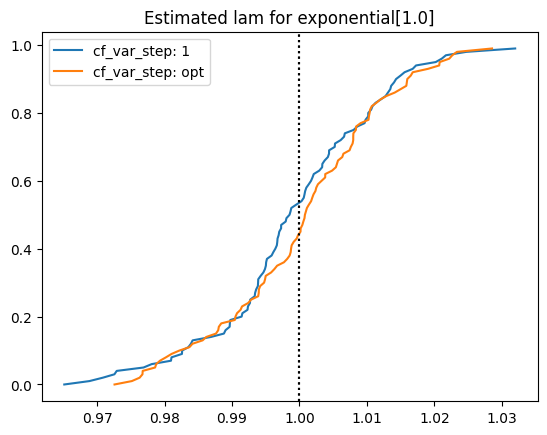

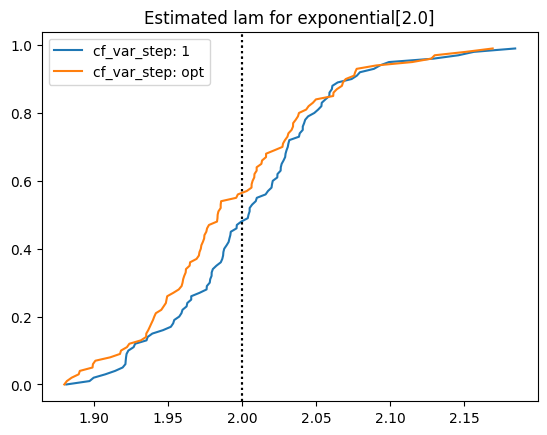

In [4]:
for Dist in Distlist:
    plot_param_dist(Dist, cf_var_step=1)
    #plot_param_dist(Dist, cf_var_step=10)
    plot_param_dist(Dist, cf_var_step=None)

## Estimating the parameter covariance matrix

Thepretically, the asymptotic covariance matrix should correspond to the covariance of the data. Here, we test if this is true.

Here, we keep `cf_var_len=10` and `cf_var_step = 1` to ensure consistent results.

The results show that in general, for $10^4$ or more samples, $\left| \widetilde{c} - c_a \right|<\widetilde{c}$ where $\widetilde{c}$ is the empirical covariance of any parameter and $c_a$ is the asymptotic covariance. This implies that if $c_a>\widetilde{c}$, we have $c_a<2\widetilde{c}$. 

There are a few issues with this:
 - The covariance is huge for a low number of samples. This is likely due to hitting the roof in the automated method.

In [ ]:
cf_var_len = 10
cf_var_step = 1
cf_var = np.arange(1,1+cf_var_len)*cf_var_step
repeat = 100

S = (10**np.arange(2,7)).astype(int)

def repeated_est_param(Dist, samples = 1000, repeat=100):

    res = np.zeros([repeat,len(Dist.params)])
    
    for i in range(repeat):
        data = Dist.realization(samples)
        rdict = fa.est_from_ECF(data, Dist.CF, cf_var_len, cf_var_step, Dist.params, bounds=Dist.param_bounds)
        res[i,:] = rdict.x[:]
    return np.cov(res.T)

def Covlist(Dist, sample_list, repeat=100):
    C = [None]*sample_list.size

    for i in range(sample_list.size):
        C[i] = repeated_est_param(Dist, sample_list[i], repeat)

    return C

In [ ]:
C = {}

for Dist in Distlist[3:4]:
    C[Dist.name+str(Dist.params)] = Covlist(Dist, S, repeat=repeat)

print(C)

In [ ]:
# Previously computed C-values as this takes time
C ={'exponential[1.0]': [np.array([0.01222913,]),
                         np.array([0.00118447,]),
                         np.array([0.00014321,]),
                         np.array([1.64569092e-05,]),
                         np.array([1.6483722e-06,])], 
    'exponential[2.0]': [np.array([0.1631969,]),
                         np.array([0.00816921,]),
                         np.array([0.00084201,]),
                         np.array([5.37740232e-05,]),
                         np.array([9.64616777e-06,])], 
    'normal[0.1, 1.0]': [np.array([[14.95631517,  0.11703477],
                                   [ 0.11703477,  0.02349359]]),
                         np.array([[0.00088938, 0.00016125],
                                [0.00016125, 0.00109806]]), 
                         np.array([[ 1.06409842e-04, -4.68631133e-06],
                                [-4.68631133e-06,  4.88110396e-05]]),
                         np.array([[1.12889727e-05, 5.83312657e-07],
                                [5.83312657e-07, 5.45267254e-06]]),
                         np.array([[ 1.10447259e-06, -1.57789835e-08],
                                [-1.57789835e-08,  6.26132396e-07]])],
    'normal[1.0, 2.0]': [np.array([[  6.75542647,  12.66809541],
                                   [ 12.66809541, 108.18925229]]),
                         np.array([[ 0.02689835, -0.00016562],
                                [-0.00016562,  0.00724598]]),
                         np.array([[3.07290982e-03, 8.78742920e-05],
                                [8.78742920e-05, 7.03826501e-04]]),
                         np.array([[2.97171135e-04, 1.74361802e-05],
                                [1.74361802e-05, 7.52710442e-05]]),
                         np.array([[2.73378295e-05, 1.27604966e-06],
                                [1.27604966e-06, 6.27333830e-06]])],
    'gamma[2.0, 1.0]': [np.array([[ 3.1009253 , -0.31174214],
                                  [-0.31174214,  0.06285058]]),
                        np.array([[ 0.01101619, -0.00582415],
                               [-0.00582415,  0.00398193]]),
                        np.array([[ 0.00083807, -0.00048914],
                               [-0.00048914,  0.00033441]]),
                        np.array([[ 6.53318216e-05, -3.63569904e-05],
                               [-3.63569904e-05,  2.62621011e-05]]),
                        np.array([[ 1.01996552e-05, -5.66532229e-06],
                               [-5.66532229e-06,  3.81446955e-06]])],
    'gammanorm[2.0]': [np.array([1.82081239,]),
                       np.array([0.06051189,]),
                       np.array([0.00685732,]),
                       np.array([0.00076608,]),
                       np.array([7.56053379e-05,])],
    'fpp[1.0, 0.1]': [np.array([[11.06670683,  4.67969232],
                                [ 4.67969232,  8.19753894]]),
                      np.array([[ 0.05215378, -0.00933553],
                             [-0.00933553,  0.00300969]]),
                      np.array([[ 2.29602475e-03, -2.60286910e-04],
                             [-2.60286910e-04,  5.53782521e-05]]),
                      np.array([[ 2.23689967e-04, -2.39406737e-05],
                             [-2.39406737e-05,  4.60190629e-06]]),
                      np.array([[ 2.17363216e-05, -2.73537801e-06],
                             [-2.73537801e-06,  5.57126191e-07]])],
   'fpp[5.0, 0.5]': [np.array([[16.77602253,  6.53668297],
                               [ 6.53668297, 19.34416004]]),
                     np.array([[14.16284356, -1.7014204 ],
                            [-1.7014204 ,  1.44898502]]), 
                     np.array([[ 5.29760922, -0.39796043],
                            [-0.39796043,  0.03579185]]), 
                     np.array([[ 0.39025319, -0.03049542],
                            [-0.03049542,  0.0028198 ]]),
                     np.array([[ 0.03545482, -0.00293915],
                            [-0.00293915,  0.00028151]])]}

In [ ]:
symb = ['o','d']
def compare_estimated_asymptotic_cov():
    for Dist in Distlist:
        fname = 'Acov - est cov comparison ' + Dist.name + str(Dist.params)
        plt.figure(fname)
        plt.title(fname)

        max_dist = np.zeros([S.size,len(Dist.params)])
        for i in range(S.size):
            AC = fa.asymptotic_covariance(cf_var,Dist.params,Dist.CF, Dist.CF_jac, S[i])

            max_dist[i,:] = np.abs((np.diag(C[Dist.name+str(Dist.params)][i])-np.diag(AC)))/np.diag(AC)
            print(Dist.name + str(Dist.params) + str(S[i]) + str(AC))
            #max_dist[i] = np.max(np.abs((C[Dist.name+str(Dist.params)][i]-AC)/C[Dist.name+str(Dist.params)][i]))

        for j in range(len(Dist.params)):
            plt.loglog(S, max_dist[:,j], symb[j],label=Dist.param_names[j])
        plt.xlabel('samples')
        plt.ylabel('relative error')
        plt.legend()

compare_estimated_asymptotic_cov()

## Covariance for correlated data

Here, we consider correlated data (an OU - process). This shows that the covariance is approximately a factor $\tau/\Delta_t$ larger than analytically suggested.

In [ ]:
def OU(samples, dt, m, s, tc):
    # m: mean value
    # s: variance in OU
    # tc: correlation time

    X = np.zeros(samples)
    N = np.random.normal(size=samples)
    eps = np.exp(-dt/tc)
    
    X[0] = N[0]
    for i in range(samples-1):
        X[i+1] = eps*X[i]+np.sqrt(1-eps**2)*N[i+1]

    return s*X+m

In [ ]:
cf_var_len = 10
cf_var_step = 1
cf_var = np.arange(1,1+cf_var_len)*cf_var_step
repeat = 100

S = (10**np.arange(2,7)).astype(int)

dt = 0.1
tc = 10

def repeated_est_param_OU(Dist, samples = 1000, repeat=100):

    res = np.zeros([repeat,2])
    
    for i in range(repeat):
        data = OU(samples,dt,*Dist.params,tc)
        rdict = sf.est_from_ECF(data, Dist.CF, cf_var_len, cf_var_step, Norm.params, bounds=Dist.param_bounds)
        res[i,:] = rdict.x[:]
    return np.cov(res.T)

def Covlist_OU(sample_list, repeat=100):
    C = [None]*sample_list.size

    for i in range(sample_list.size):
        C[i] = repeated_est_param_OU(Norm, sample_list[i], repeat)

    return C

In [ ]:
Covlist_OU(S)

In [ ]:
COU_tc1 = [np.array([[ 15.45652558,  11.39934525], 
                     [ 11.39934525, 475.47832575]]),
           np.array([[ 0.81715021, -0.03424193],
                     [-0.03424193,  0.01332925]]),
           np.array([[1.57472733e-03, 6.92491660e-05],
                     [6.92491660e-05, 5.61747461e-04]]),
           np.array([[1.96736487e-04, 1.09362928e-05],
                     [1.09362928e-05, 5.69904509e-05]]),
           np.array([[1.54764429e-05, 7.79976474e-07],
                     [7.79976474e-07, 6.13191102e-06]])]

COU_tc10 = [np.array([[  58.70862553,  -58.97281148],
                      [ -58.97281148, 2518.05804767]]),
            np.array([[11.46387616, 10.64258916],
                      [10.64258916, 98.95127457]]), 
            np.array([[ 0.02689952, -0.0013184 ],
                      [-0.0013184 ,  0.00773537]]),
            np.array([[0.00160671, 0.00019614],
                      [0.00019614, 0.00038287]]),
            np.array([[ 2.24680314e-04, -1.75872657e-05],
                      [-1.75872657e-05,  5.16877244e-05]])]

In [ ]:
for i in range(1,5):
    print(COU_tc1[i]/C['normal[0.1, 1.0]'][i])

In [ ]:
for i in range(1,5):
    print(COU_tc10[i]/C['normal[0.1, 1.0]'][i])

## Test for multimachine-values

Here, we look for multimachine-values. We take the fitted gamma, e=0.1 and the fitted td.

The covariance is estimated as $2 (\tau_\mathrm{d}/\Delta_t)$ times the asymptotic covariance matrix.

All time values in microseconds.

In [ ]:
Cmod = {'g':[3.3,4.1,2.8,2.2,1.4,1.1,1.1,1.3,0.85,0.87,0.82,0.76,0.71],
        'td':[12,4.2,5.1,9.3,11,9.1,9.0,4.3,9.5,8.6,6.9,8.5,8.2],
        'dt':1/3.3,
        'T':np.array([0.27,0.67,1.,0.8,0.35,0.8,0.8,0.4,0.5,0.5,0.5,0.35,0.35])*1e6}

DIIID = {'g':[5.4,3.3,4.2,4.4,2.5],
        'td':[5.4,6.7,7.1,8.1,5.2],
        'dt':1/4,
        'T':np.array([6.8,7.6,7.5,7.5,7.4])*1e3}

MAST = {'g':[0.88,0.86,0.68,0.69,0.74,0.5,0.67,0.53,0.59],
        'td':[12,11,15,16,13,18,16,20,17],
        'dt':1.,
        'T':np.array([41,27,13,15,14,20,15,15,14])*1e3}

MASTU = {'g':[1.2,0.97,0.84,0.58],
        'td':[15,24,28,30],
        'dt':1,
        'T':np.array([300,400,100,144])*1e3}

cf_var = np.arange(1,11)

def print_error(machine):
    for i in range(len(machine['g'])):
        samples = int(machine['T'][i]/machine['td'][i])
        Dist = FPP.change_params([machine['g'][i],0.1])
        acov = sf.asymptotic_covariance(cf_var,Dist.params,Dist.CF, Dist.CF_jac, samples)
    
        print(2*acov)

print_error(DIIID)

In [ ]:
cf_var = np.arange(1,11)*2

for g in [0.1,1,10]:
    Dist = FPP.change_params([g,0.1])
    print(sf.asymptotic_covariance(cf_var,Dist.params,Dist.CF, Dist.CF_jac, 1))